In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
# from lib import rda,csa,wka, sarlib, util



In [2]:
def peak_find(input,interval=10,num=3):
    idx = []
    data = np.abs(input)
    
    for i in range(num):
        idx_i=list(zip(*np.where(data==np.max(data))))
        idx.append(idx_i[0])
        data[idx_i[0][0]-interval//2:idx_i[0][0]+interval//2,idx_i[0][1]-interval//2:idx_i[0][1]+interval//2]=0

    return idx

# plot the data in dB scale
def image_plot_dB(data):
    plot_size_az = 20000
    plot_size_rg = 20000
    if len(data) > plot_size_az:
        az_l = len(data) // 2 - plot_size_az // 2
        az_u = len(data) // 2 + plot_size_az // 2
    else:
        az_l = 0
        az_u = len(data)
    if len(data[0]) > plot_size_rg:
        rg_l = len(data[0]) // 2 - plot_size_rg // 2
        rg_u = len(data[0]) // 2 + plot_size_rg // 2
    else:
        rg_l = 0
        rg_u = len(data[0])
    plot_data = np.abs(data[az_l:az_u, rg_l:rg_u])
    norm_factor = np.max(plot_data)
    plot_data = plot_data / norm_factor
    threshould_dB = 60
    plot_data = np.ceil(plot_data * 10 ** (threshould_dB / 20)) / 10 ** (
        threshould_dB / 20
    )
    plt.imshow(20 * np.log10(plot_data), cmap="gray")

    plt.colorbar()
    plt.show()

    return

In [3]:
# constants
c = 299792456

In [4]:
# radar parameters
chirp_bw = 75e6 #75e6
fc = 9.65e9
wl = c/fc
fs = 100e6
prf = 4000
pri = 1/prf
duty = 0.25 #3e-6*prf #0.25
chirp_len = pri*duty
chirp_rate = chirp_bw/chirp_len

chirp_mode = "down" # up, down, ud

In [5]:
# platform parameters
l_a = 4.9
w_a = 0.7
theta_l = 30 * np.pi/180
height = 550e3
r_sc = 690e3
# r0 = height/np.cos(theta_l)
veff = 7410
squint = 0.0/180*np.pi
doppler_centroid = 2*veff*np.sin(squint)/wl


In [6]:
# antenna pattern
theta_l_a = 0.886*wl/l_a
theta_w_a = 0.886*wl/w_a

In [7]:
# transmitted chirp pulse
time_duration = chirp_len*fs
t = np.arange(-time_duration/2,time_duration/2,1)/fs
phase = np.pi*chirp_rate*t**2
chirp_replica_u = np.exp(1j*phase) # up chirp
chirp_replica_d = np.exp(-1j*phase) # down chirp

In [8]:
# simlation swath
range_swath = 10e3
azimuth_swath = 10e3

# range time (fast time)
time_duration = (range_swath**2+azimuth_swath**2)**0.5/c
nsamples = np.ceil(time_duration*fs).astype(int) + len(chirp_replica_u)
fast_time = np.arange(0,nsamples,1)/fs + 2*r_sc/c
rg_array = c*fast_time+r_sc

# azimuth time
time_duration = azimuth_swath/veff
npulses = np.ceil(time_duration*prf).astype(int)
slow_time = np.arange(-npulses//2,npulses//2,1)/prf
az_array = veff*slow_time+r_sc*np.tan(squint)


In [9]:
# point target
points = [(r_sc+range_swath/2,0)]
#points = [(r_sc+range_swath/100,0)]#for test

In [10]:
# response from point target
iq_data = np.zeros((len(slow_time),len(fast_time)),dtype=np.complex64)
t_chirp = np.zeros(len(fast_time),dtype=np.complex64)
chirp_l = len(chirp_replica_u)
t_chirp[:len(chirp_replica_u)] = chirp_replica_u
t_chirp_f = np.fft.fft(t_chirp)

phi_offset = np.pi*0
sample_delay = 0

rg_freq = np.arange(-0.5,0.5,1/len(fast_time))*fs
rg_freq -=rg_freq[len(rg_freq)//2]
if chirp_mode == "up" or chirp_mode == "ud":
    ss = 1
else:
    ss = -1

for i in range(len(slow_time)):
    if chirp_mode == "ud":
        ss *= -1

    for j in range(len(points)):
        # i-th azimuth position
        az = az_array[i]
        # distance between radar and target at i-th azimuth position
        r = (points[j][0]**2+(points[j][1]-az)**2)**0.5
        # angle between radar and target at i-th azimuth position
        angle_to_target = np.arctan((az-points[j][1])/points[j][0])
        # amplitude change accoding to azimuth antenna pattern
        s_az = np.sinc((angle_to_target-squint)/theta_l_a)**2

        # rectangular window
        rect = np.zeros(len(fast_time))
        rect[int(2*(r-r_sc)/c*fs):int(2*(r-r_sc)/c*fs+chirp_l)] = 1

        # echo from point target
        iq_data[i,:] += rect*np.exp(ss*1j*np.pi*chirp_rate*(fast_time-2*(r)/c-chirp_len/2)**2)*np.exp(-4j*np.pi*r/wl)*s_az+1e-10
        #NG iq_data[i,:] += rect*np.exp(ss*1j*np.pi*chirp_rate*(fast_time-2*(r)/c-chirp_len/2)**2)*s_az+1e-10


        # phase offset btw up and down chirp
        # iq_data[i,:] *= np.exp(1j*phi_offset*(i%2))
        # iq_data[i,:] = np.roll(iq_data[i,:],(i%2)*sample_delay)


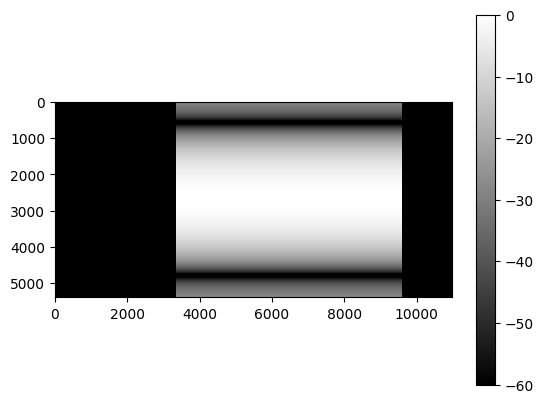

In [11]:
image_plot_dB(iq_data)

In [12]:
# preparation of range reference function
t_chirp_u = np.zeros(len(iq_data[0]),dtype=np.complex64)
t_chirp_d = np.zeros(len(iq_data[0]),dtype=np.complex64)
chirp_l = len(chirp_replica_u)
t_chirp_u[:len(chirp_replica_u)] = chirp_replica_u
t_chirp_d[:len(chirp_replica_d)] = chirp_replica_d

# convert to frequency domain
t_chirp_u_f = np.fft.fft(t_chirp_u)
t_chirp_d_f = np.fft.fft(t_chirp_d)


In [13]:
# range compression
# レンジ方向に周波数ドメインに変換し、リファレンス信号との相関を取る。その後、周波数ドメインから時間ドメインに戻す。
iq_data_f = np.fft.fft(iq_data,axis=1)
iq_rg_cmp = np.zeros_like(iq_data)
for i in range(iq_data.shape[0]):
    if chirp_mode == "up" or (chirp_mode =="ud" and i%2==1):
        iq_rg_cmp[i,:] = np.fft.ifft(iq_data_f[i,:]*np.conj(t_chirp_u_f))
    else:
        iq_rg_cmp[i,:] = np.fft.ifft(iq_data_f[i,:]*np.conj(t_chirp_d_f))

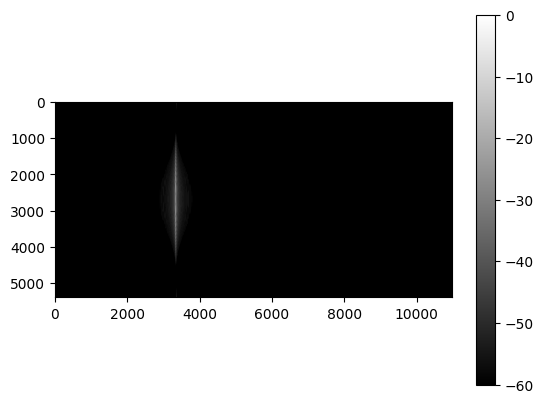

In [14]:
image_plot_dB(iq_rg_cmp)

In [15]:
# azimuth fft (rd: range-doppler domain, azimuth frequency domain)
iq_data_rd = np.fft.fftshift(np.fft.fft(iq_rg_cmp,axis=0),axes=0)


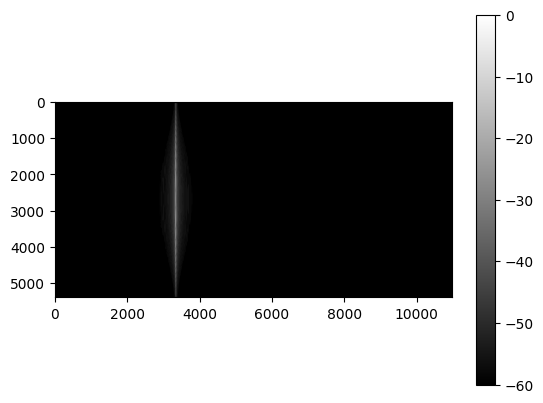

In [16]:
image_plot_dB(iq_data_rd)

In [17]:
# RCMC (range cell migration correction)
data_len = iq_data_rd.shape[0]
sample_points = np.arange(-(data_len) // 2, data_len // 2)
freq = sample_points * (prf / data_len) + doppler_centroid
freq = np.roll(
    freq, np.round(doppler_centroid / (prf / data_len)).astype(int)
)
rcm = np.zeros(iq_data_rd.shape, np.float64)
d_rg = c/2/fs
for i in range(iq_data_rd.shape[1]):
    rcm[:, i] = (1 / np.sqrt(1 - (wl * freq / (2 * veff)) ** 2) - 1) * (r_sc + d_rg * i)

R = r_sc + np.arange(0, iq_data_rd.shape[1]) * d_rg
R_new = np.tile(R, (rcm.shape[0], 1)) + rcm

# data_rcmc = np.zeros_like(data)
iq_data_rcmc = np.zeros_like(iq_data_rd)
for i in range(iq_data_rd.shape[0]):
    f = interpolate.interp1d(R, iq_data_rd[i], kind="cubic", fill_value="extrapolate")
    iq_data_rcmc[i] = f(R_new[i])


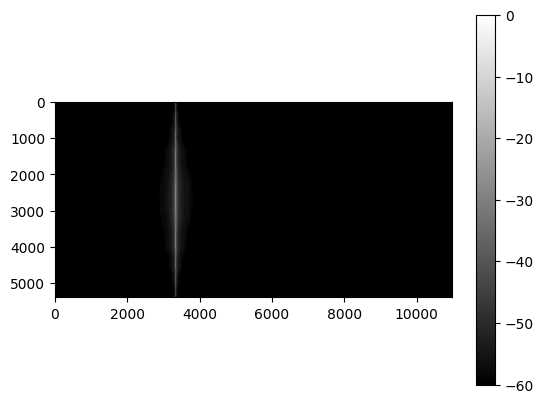

In [18]:
image_plot_dB(iq_data_rcmc)

In [19]:
# azimuth chirp signal generation
def azimuth_chirp(doppler_centroid, tau, fm_rate):
    dt = 1 / prf
    n_points = np.floor(tau * prf).astype(int)
    t = np.arange(-n_points // 2, n_points // 2) * dt
    phase = 2 * np.pi * doppler_centroid * t + np.pi * fm_rate * t**2
    chirp = np.exp(1j * phase)
    return chirp

# azimuth reference function generation
def azimuth_reference(ri, datalen):
    # squint range
    ri = ri / np.sqrt(1 - (wl * doppler_centroid) / (2 * veff) ** 2)
    # azimuth fm rate
    fm_rate = -(2 * veff**2 / wl) / ri
    # azimuth beam width
    az_beamwidth = ri * (wl / l_a) * 1.2
    # azimuth pulse length
    tau_az = az_beamwidth / veff

    # reference chirp signal
    az_ref = azimuth_chirp(doppler_centroid, tau_az, fm_rate)
    az_ref_len = len(az_ref)
    az_ref_padded = np.zeros(datalen, np.complex64)
    az_ref_padded[:az_ref_len] = az_ref
    # az_ref = np.roll(az_ref_padded, - az_ref_len//2+len(az_ref_padded)//2)
    # az_ref = np.roll(az_ref_padded, len(az_ref_padded)//2)
    shift = az_ref_len//2 + int(-(2*(doppler_centroid)/fm_rate)*prf)//2
    az_ref = np.roll(az_ref_padded, - shift)

    return az_ref

# azimuth compression
def azimuth_compression(data):
    datalen = data.shape[0]
    for i in range(len(data[0])):
        ri = r_sc + c / (2 * fs) * i
        az_ref = azimuth_reference(ri, datalen)
        az_ref = np.conj(np.fft.fftshift(np.fft.fft(az_ref))).astype(np.complex64)
        data[:, i] = data[:, i] * az_ref
    return data

In [20]:
# azimuth compression
iq_az_cmp = azimuth_compression(iq_data_rcmc)

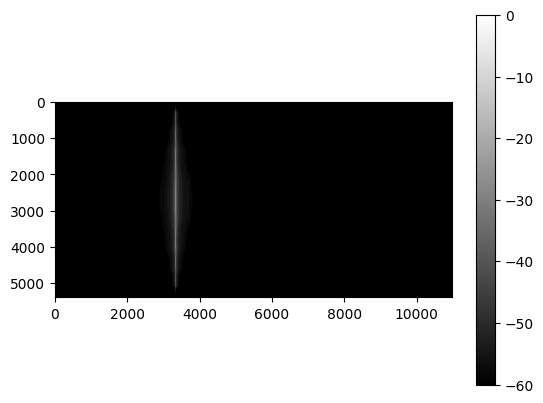

In [21]:
image_plot_dB(iq_az_cmp)

In [22]:
# azimuth ifft
slc = np.fft.ifft(np.fft.fftshift(iq_az_cmp,axes=0),axis=0)


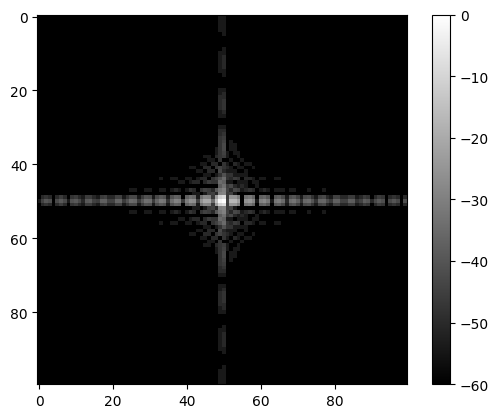

In [23]:
peak_idx = peak_find(slc, interval=10, num=1)
plot_len = 100
image_plot_dB(slc[peak_idx[0][0]-plot_len//2:peak_idx[0][0]+plot_len//2,peak_idx[0][1]-plot_len//2:peak_idx[0][1]+plot_len//2])

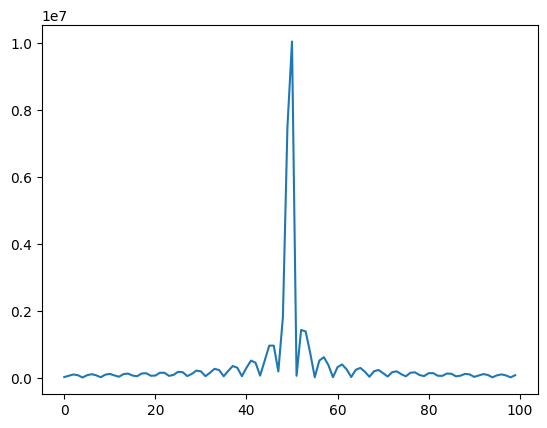

In [24]:
# range profile
plot_len = 100
plt.plot(np.abs(slc[peak_idx[0][0],peak_idx[0][1]-plot_len//2:peak_idx[0][1]+plot_len//2]))

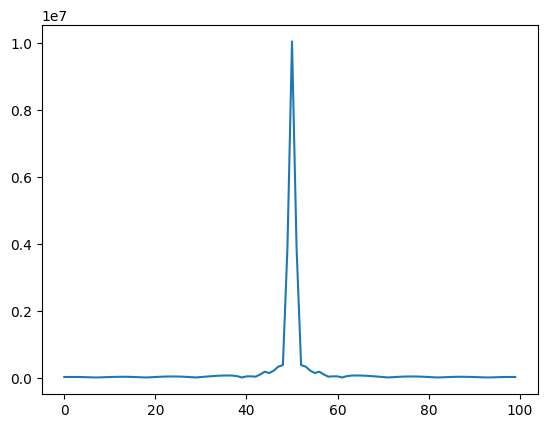

In [25]:
# azimuth profile
plot_len = 100
plt.plot(np.abs(slc[peak_idx[0][0]-plot_len//2:peak_idx[0][0]+plot_len//2,peak_idx[0][1]]))

In [26]:
from scipy.signal import peak_widths

def resolution_estimation(data, interp_ratio=10):
    data = np.abs(data)
    idx = np.argmax(data)

    range_cut = data[idx // data.shape[1]]
    azimuth_cut = data[:, idx % data.shape[1]]

    range_cut = np.abs(fft_interp(range_cut, interp_ratio)) ** 2
    peak_idx_rg = [np.argmax(range_cut)]
    width_rg = peak_widths(range_cut, peak_idx_rg, rel_height=0.5)

    azimuth_cut = np.abs(fft_interp(azimuth_cut, interp_ratio)) ** 2
    peak_idx_az = [np.argmax(azimuth_cut)]
    width_az = peak_widths(azimuth_cut, peak_idx_az, rel_height=0.5)

    return width_rg[0] / interp_ratio, width_az[0] / interp_ratio

# fft interpolator
def fft_interp(sig, interp_ratio):
    sig_f = np.fft.fftshift(np.fft.fft(sig))
    tmp = np.zeros(len(sig) * interp_ratio, dtype=np.complex64)
    tmp[0 : len(sig_f)] = sig_f
    tmp = np.roll(tmp, len(tmp) // 2 - len(sig_f) // 2)
    return np.fft.ifft(np.fft.fftshift(tmp)).astype(np.complex64)


In [27]:
d_rg = c/2/fs
d_az = veff/prf
res_rg, res_az = resolution_estimation(slc)
print("range resolution: ", res_rg*d_rg)
print("azimuth resolution: ", res_az*d_az)

range resolution:  [1.78550574]
azimuth resolution:  [2.29074928]


In [28]:
points = [(r_sc+range_swath/3,0)]
points

[(693333.3333333334, 0)]

In [29]:
print(iq_data[1,:])

[1.e-10+0.j 1.e-10+0.j 1.e-10+0.j ... 1.e-10+0.j 1.e-10+0.j 1.e-10+0.j]


c:\Users\yosit\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\yosit\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


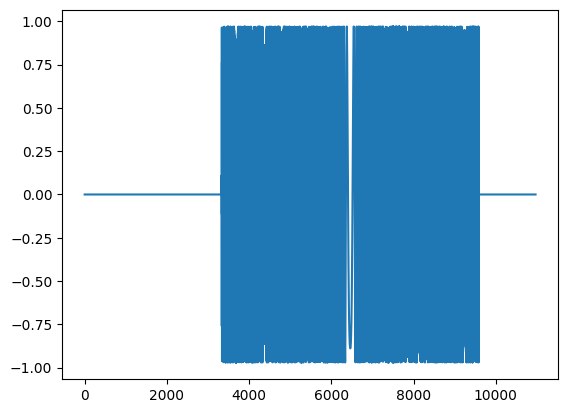

In [30]:
plt.plot(iq_data[2500,:])

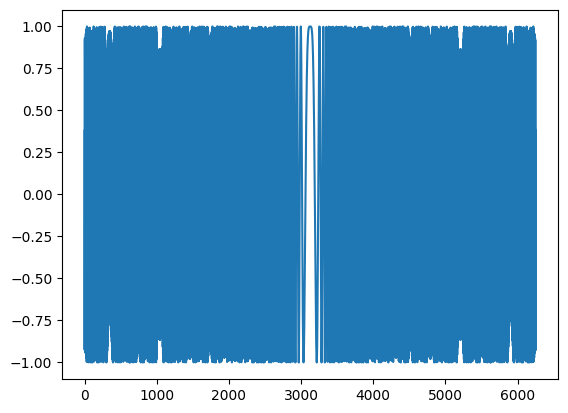

In [31]:
phase = np.pi*chirp_rate*t**2
chirp_replica_u = np.exp(1j*phase) # up chirp
plt.plot(chirp_replica_u)

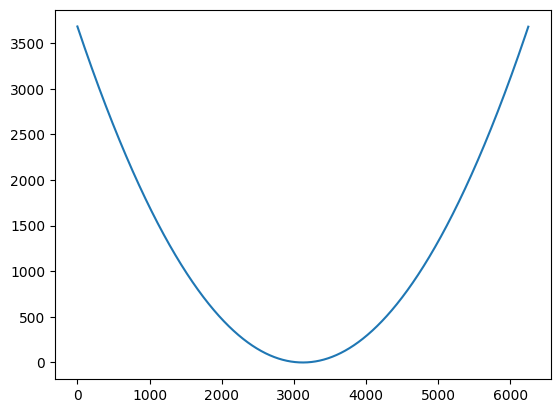

In [32]:
plt.plot(phase)